# Projeto de Data Science - Superstore


## Contexto

Os dados analisados representam o histórico de vendas de uma empresa varejista, contendo informações sobre clientes, produtos, localização, descontos e lucro.

## Objetivo

O objetivo deste projeto é:

* Organizar e tratar os dados
* Gerar indicadores relevantes
* Identificar padrões e oportunidades
* Desenvolver uma abordagem preditiva para antecipar prejuízos

## Estratégia

O projeto foi estruturado em quatro etapas:

1. Tratamento dos dados
2. Análise exploratória
3. Modelagem preditiva
4. Recomendações e evolução

### Autor: Julia Jóia

## Resumo executivo
1. **Política de Descontos:** Descontos acima de 20% são o principal preditor de prejuízo.
2. **Eficiência Logística:** O tempo médio de entrega (Lead Time) impacta a retenção, mas não o lucro imediato.
3. **Categorias Críticas:** A categoria 'Furniture' apresenta as menores margens, apesar do alto volume.

In [ ]:
# Imports e entendimento dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("data/superstore.csv", encoding='latin1')

df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   str    
 1   Order Date     9994 non-null   str    
 2   Ship Date      9994 non-null   str    
 3   Ship Mode      9994 non-null   str    
 4   Customer ID    9994 non-null   str    
 5   Customer Name  9994 non-null   str    
 6   Segment        9994 non-null   str    
 7   Country        9994 non-null   str    
 8   City           9994 non-null   str    
 9   State          9994 non-null   str    
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   str    
 12  Product ID     9994 non-null   str    
 13  Category       9994 non-null   str    
 14  Sub-Category   9994 non-null   str    
 15  Product Name   9994 non-null   str    
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount       9994

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [31]:
#Verificação de linhas duplicadas

# Verificar a quantidade total de linhas duplicadas
print(f"Quantidade de linhas duplicadas: {df.duplicated().sum()}")

# Visualizar quais são as linhas duplicadas
if df.duplicated().sum() > 0:
    display(df[df.duplicated(keep=False)].sort_values(by='Order ID'))
    
# Remover duplicatas
df.drop_duplicates(inplace=True)

print(f"Tamanho do dataset após remover duplicatas: {df.shape[0]} linhas")

Quantidade de linhas duplicadas: 1


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
385,US-2019-150119,2019-04-23,2019-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
386,US-2019-150119,2019-04-23,2019-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


Tamanho do dataset após remover duplicatas: 9993 linhas


### Observações iniciais

* A base apresenta estrutura consistente, sem grande volume de dados faltantes
* As variáveis estão majoritariamente bem definidas
* Há potencial para criação de variáveis derivadas que agreguem valor analítico


In [32]:
# Tratamento dos dados e feature engineering

# Padronizando colunas de data
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculando tempo de entrega
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Calculando margem de lucro
df['Profit Margin'] = df['Profit'] / df['Sales']

# Calculando prejuízo
df['Loss'] = np.where(df['Profit'] < 0, 1, 0)

print(f"Dataset carregado: {df.shape[0]} registros.")
df[['Order Date', 'Ship Date', 'Lead Time', 'Profit Margin']].head()

Dataset carregado: 9993 registros.


,Order Date,Ship Date,Lead Time,Profit Margin
0,2019-01-03,2019-01-07,4,0.3375
1,2019-01-04,2019-01-08,4,0.3625
2,2019-01-04,2019-01-08,4,-0.2375
3,2019-01-04,2019-01-08,4,-1.5500
4,2019-01-05,2019-01-12,7,0.2500


In [33]:
# Exportar base limpa e consolidada (fase opcional)
df.to_csv('superstore_clean.csv', index=False, encoding='utf-8')

print("Base de dados exportada")

Base de dados exportada


## Criação de variáveis

Foram criadas variáveis adicionais com o objetivo de enriquecer a análise:

* Tempo de entrega: permite avaliar eficiência logística
* Margem de lucro: melhora a análise de rentabilidade
* Indicador de prejuízo: fundamental para modelagem preditiva


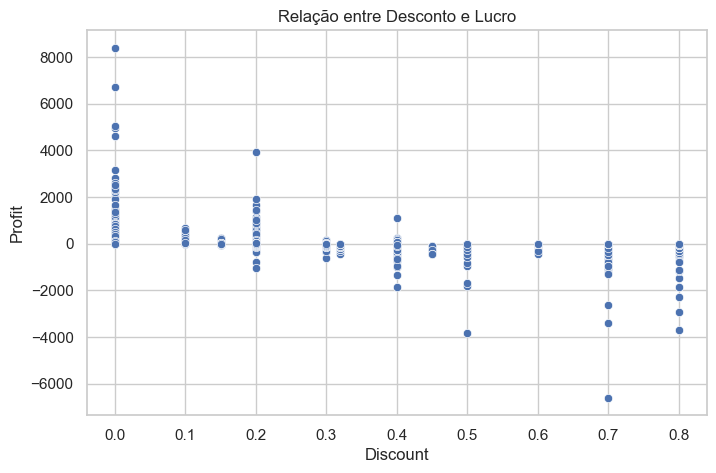

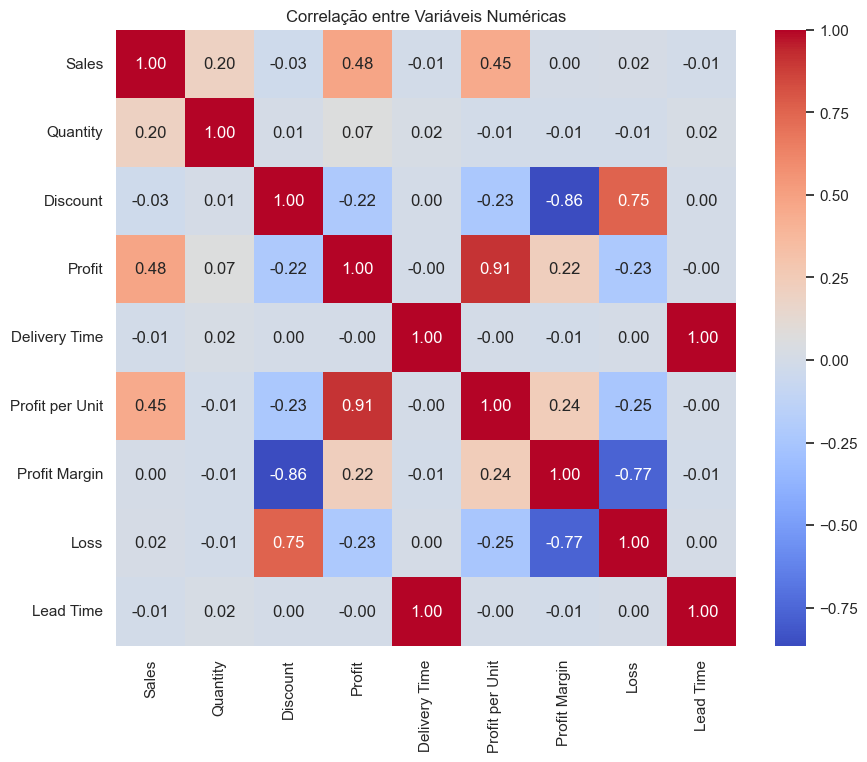

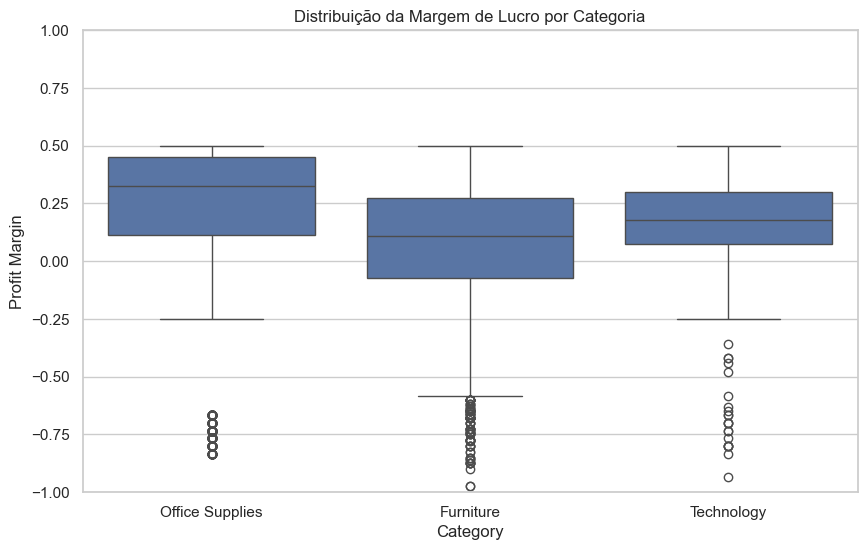

In [ ]:
# Indicadores principais
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin = total_profit / total_sales

total_sales, total_profit, margin

# Receita por categoria
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Lucro por categoria 
df.groupby('Category')['Profit'].sum().sort_values()

# Lucro por regiao
df.groupby('Region')['Profit'].sum().sort_values()

# Desconto vs lucro
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Relação entre Desconto e Lucro')
plt.show()

# Matriz de correlação para validar hipóteses
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Postal Code'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação entre Variáveis Numéricas")
plt.show()

#Bloxpot de Margem por Categoria para identificar outliers
sns.boxplot(x='Category', y='Profit Margin', data=df)
plt.ylim(-1, 1) # Limitando para melhor visualização do centro
plt.title("Distribuição da Margem de Lucro por Categoria")
plt.show()

### Principais Insights
* Descontos elevados estão fortemente associados a prejuízos
* Algumas categorias apresentam lucro negativo mesmo com alto volume de vendas
* Há regiões com desempenho significativamente inferior, indicando possível ineficiência operacional
* O aumento de vendas não necessariamente implica aumento de lucro

### Análise de Correlação
* Observamos uma correlação negativa forte entre **Discount** e **Profit**. Isso confirma que o aumento indiscriminado de descontos destrói a margem de lucro.
* O **Lead Time** não apresenta correlação direta com o lucro, sugerindo que o custo logístico de velocidade está bem precificado ou é absorvido.


# Modelagem Preditiva 
### Problema proposto
Prever se uma venda resultará em lucro ou prejuízo. Essa abordagem permite antecipar decisões e evitar perdas financeiras.

In [20]:
# Preparação dos dados
features = ['Sales', 'Quantity', 'Discount', 'Lead Time', 'Category', 'Region', 'Segment']
X = df[features].copy()
y = df['Loss']

# Encoding de variáveis categóricas
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

/var/folders/1f/9v1z92454s594ryjdlqgrsmw0000gn/T/ipykernel_30581/1914594485.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


In [21]:
# Modelo RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

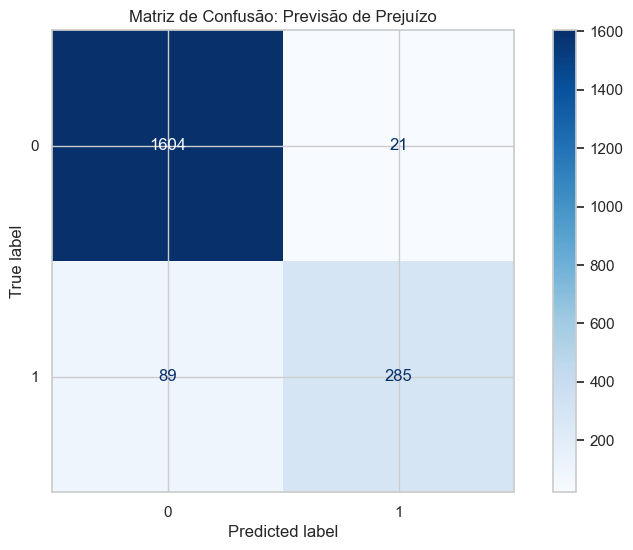

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1625
           1       0.93      0.76      0.84       374

    accuracy                           0.94      1999
   macro avg       0.94      0.87      0.90      1999
weighted avg       0.94      0.94      0.94      1999



In [22]:
# Matriz de Confusão (Essencial para problemas de classificação)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão: Previsão de Prejuízo")
plt.show()

# Relatório de Classificação
print(classification_report(y_test, y_pred))

/var/folders/1f/9v1z92454s594ryjdlqgrsmw0000gn/T/ipykernel_30581/2253546655.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


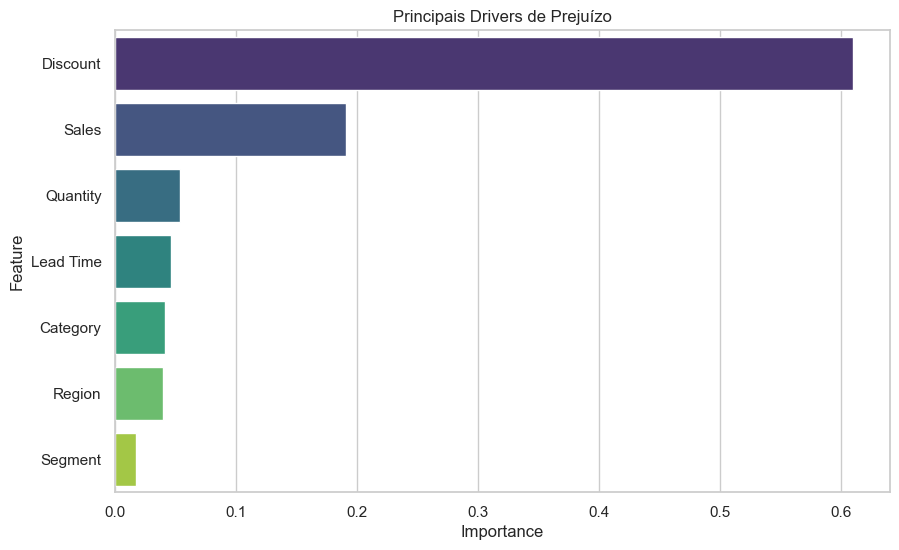

In [ ]:
# Importancia das variáveis
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Principais Drivers de Prejuízo')
plt.show()

## Interpretação do modelo

O modelo identificou o desconto como principal variável associada ao prejuízo. Isso indica que políticas agressivas de desconto aumentam significativamente o risco de perdas.

Outras variáveis, como categoria e região, também influenciam, mas com menor impacto.

O modelo atual possui alta precisão, mas podemos melhorar o Recall do prejuízo para garantir que menos vendas "ruins" passem despercebidas.


## Recomendações

* Revisar políticas de desconto, principalmente em níveis elevados
* Monitorar produtos e categorias com histórico de prejuízo
* Direcionar estratégias para regiões mais lucrativas
* Utilizar o modelo preditivo como ferramenta de apoio à decisão


## Evolução da base de dados

Sugestões de melhoria:

* Inclusão do custo dos produtos (essencial para análise real de lucro)
* Dados de estoque
* Histórico de comportamento do cliente
* Informação de prazo prometido vs entrega real

Com esses dados, seria possível evoluir para:

* Previsão de demanda
* Otimização de preços
* Segmentação de clientes
